In [1]:
import r2l
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# 一步Sarsa算法

Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 17290.39it/s, episode=500, return=-18.900]


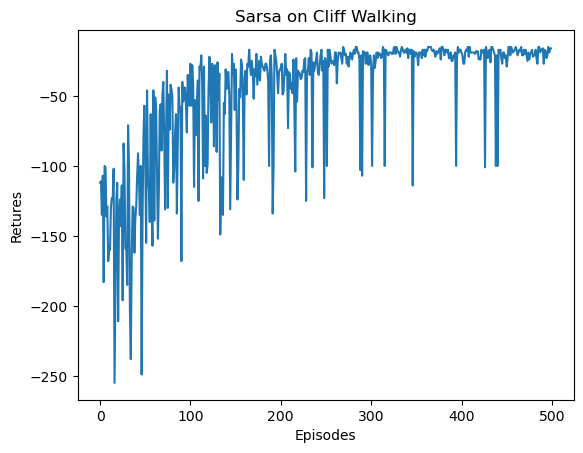

In [2]:
ncol = 12 
nrow = 4
env = r2l.CliffWalkingEnv_ch5(ncol, nrow)
np.random.seed(0)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = r2l.Sarsa(ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500 # 智能体在环境中运行的序列的数量

return_list = [] # 记录每一条序列的回报
for i in range(10):# 显示10个进度条
    with tqdm(total=int(num_episodes/10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):#每个进度条的序列数
            episode_return = 0
            state = env.reset()
            action = agent.take_action(state)
            done = False
            while not done:
                next_state, r, done = env.step(action)
                next_action = agent.take_action(next_state)
                episode_return += r # 不进行折扣因子衰减
                agent.update(state, action, r, next_state, next_action)
                state = next_state
                action = next_action
            return_list.append(episode_return)

            if (i_episode+1) % 10 == 0: # 每10条序列打印一下十条序列的平均回报
                pbar.set_postfix({'episode': '%d' % (num_episodes / 10 * i +
                                i_episode + 1), 'return': '%.3f' % np.mean(return_list[-10:]) })
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Retures')
plt.title('Sarsa on {}'.format('Cliff Walking'))
plt.show()




In [6]:
action_meaning = ['⬅️', '⬇️', '➡️', '⬆️'] # gym 预先设定好的动作含义

print("Sarsa 算法最终收敛得到的策略为：")
r2l.print_agent_ch4(agent, env, action_meaning, list(range(37, 47)), [47])


Sarsa 算法最终收敛得到的策略为：
🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️⬇️🅾️🅾️ 
⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ 🅾️🅾️➡️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ ⬅️🅾️🅾️🅾️ 🅾️⬇️🅾️🅾️ 
🅾️🅾️🅾️⬆️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ ⬅️🅾️🅾️🅾️ 🅾️🅾️🅾️⬆️ 🅾️⬇️🅾️🅾️ 
⬅️🅾️🅾️🅾️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ✅✅✅✅ 


# n步Sarsa算法

In [4]:
np.random.seed(0)
n_step = 5 # 5 步Sarsa算法
alpha = 0.1
epsilon = 0.1
gamma = 0.9
agent = r2l.nstep_Sarsa(n_step, ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500 # 智能体在环境中运行的序列的数量

return_list = [] # 记录每一条序列的回报
for i in range(10):
    with tqdm(total=int(num_episodes/10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):
            episode_return = 0
            state = env.reset()
            action = agent.take_action(state)
            done = False
            while not done:
                next_state, reward, done = env.step(action)
                next_action = agent.take_action(next_state)
                episode_return += reward
                agent.update(state, action, reward, next_state, next_action, done)
                state = next_state
                action = next_action
            return_list.append(episode_return)
            if (i_episode % 10 == 0): # 每10条序列的平均回报
                pbar.set_postfix({'episode' : '%d' % (num_episodes / 10 * i + i_episode + 1),
                                  'return' : '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)

Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 13803.41it/s, episode=491, return=-19.600]


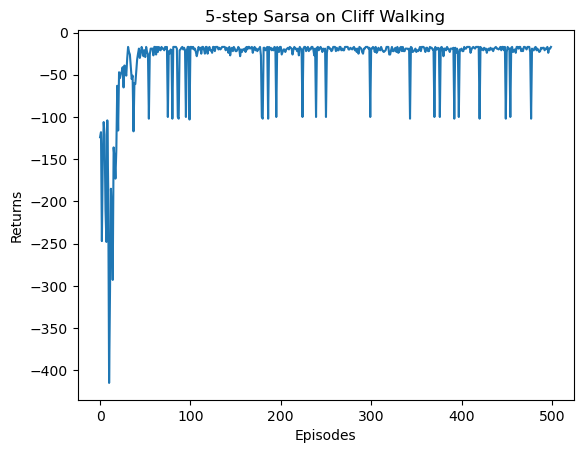

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('5-step Sarsa on {}'.format('Cliff Walking'))
plt.show()

In [8]:
print('算法最终收敛得到的策略为')
r2l.print_agent_ch4(agent, env, action_meaning, list(range(37, 47)), [47])

算法最终收敛得到的策略为
🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ 🅾️⬇️🅾️🅾️ 
⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ 🅾️🅾️➡️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ ⬅️🅾️🅾️🅾️ 🅾️⬇️🅾️🅾️ 
🅾️🅾️🅾️⬆️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ ⬅️🅾️🅾️🅾️ 🅾️🅾️🅾️⬆️ 🅾️🅾️🅾️⬆️ ⬅️🅾️🅾️🅾️ 🅾️🅾️🅾️⬆️ 🅾️⬇️🅾️🅾️ 
⬅️🅾️🅾️🅾️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ⚠️⚠️⚠️⚠️ ✅✅✅✅ 
